## Day 5 — Unit Vectors & Cosine Similarity

In [ ]:
import numpy as np

#### To find a unit vector, we need to follow the below steps:
- Find the magnitude of the vector
- Divide the vector by its magnitude

In [ ]:
v = np.array([3,4])
v_unit = v / np.linalg.norm(v)
print(v_unit) # [0.6, 0.8]
print(np.linalg.norm(v_unit)) # 1.0

[0.6 0.8]
1.0


#### To find the cosine similarity between two vectors, we need to follow the below steps:
- Find the dot product of the two vectors
- Find the magnitude of each vector
- Divide the dot product by the product of the magnitudes of the two vectors

**Cosine similarity** is nothing but the angle between two vectors. The closer the angle is to 0, the more similar the vectors are. The closer the angle is to 90 degrees, the less similar the vectors are. The closer the angle is to 180 degrees, the more dissimilar the vectors are.Unit Vectors & Cosine Similarity



In [7]:
vector_a = np.array([3, 4])
vector_b = np.array([2, 2])

cos_sim = np.dot(vector_a, vector_b) / (
    np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
)
print(cos_sim)

0.9899494936611665


##### Test: cosine_sim of [1,0] and [1,0] = 1.0, and [1,0] and [-1,0] = -1.0

In [9]:
vector_a = np.array([1, 0])
vector_b = np.array([1, 0])

cos_sim = np.dot(vector_a, vector_b) / (
    np.linalg.norm(vector_a) * np.linalg.norm(vector_b)
)

print(cos_sim)

1.0


In [10]:
vector_a = np.array([1, 0])
vector_b = np.array([-1, 0])
cos_sim = np.dot(vector_a, vector_b) / (
    np.linalg.norm(vector_a) / np.linalg.norm(vector_b)
)
print(cos_sim)

-1.0


#### Practice: given 4 made-up word vectors (2D), find the two most similar using cosine similarity

In [13]:
word_vectors = {
    "zara": np.array([0.8, 0.6]),
    "blip": np.array([0.5, 0.9]),
    "quix": np.array([0.7, 0.7]),
    "vorn": np.array([-0.3, 0.8]),
    "flim": np.array([0.6, 0.5]),
}


def cosine_similarity(a, b):
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)


words = list(word_vectors.keys())
similarities = []


for i in range(len(words)):
    for j in range(i + 1, len(words)):
        word1 = words[i]
        word2 = words[j]
        vec1 = word_vectors[word1]
        vec2 = word_vectors[word2]

        sim = cosine_similarity(vec1, vec2)
        similarities.append((word1, word2, sim))

sorted_similarities = sorted(similarities, key=lambda x: x[2], reverse=True)
most_similar = sorted_similarities[0]
least_similar = sorted_similarities[-1]

print("Most similar:", most_similar)
print("Least similar:", least_similar)
for w1, w2, sim in sorted_similarities:
    print(f"{w1} vs {w2}: {sim:.4f}")

Most similar: ('zara', 'flim', np.float64(0.9986876634765887))
Least similar: ('zara', 'vorn', np.float64(0.2808987532707133))
zara vs flim: 0.9987
quix vs flim: 0.9959
zara vs quix: 0.9899
blip vs quix: 0.9615
blip vs flim: 0.9327
zara vs blip: 0.9130
blip vs vorn: 0.6480
quix vs vorn: 0.4138
vorn vs flim: 0.3297
zara vs vorn: 0.2809


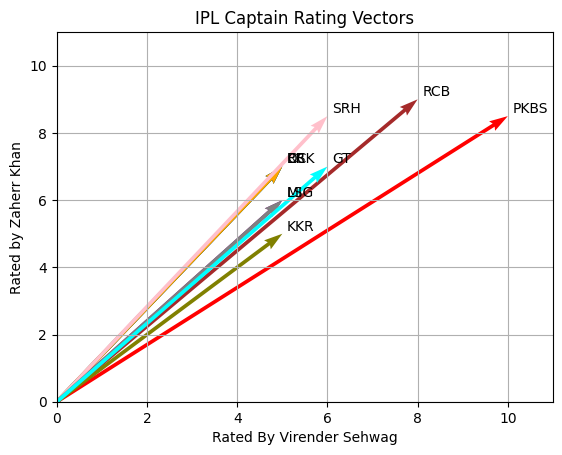

In [23]:
import matplotlib.pyplot as plt

ipl_captain_ratings = {
    "PKBS": np.array([10, 8.5]),
    "DC": np.array([5, 7]),
    "CSK": np.array([5, 7]),
    "RR": np.array([5, 7]),
    "LSG": np.array([5, 6]),
    "RCB": np.array([8, 9]),
    "SRH": np.array([6, 8.5]),
    "MI": np.array([5, 6]),
    "KKR": np.array([5, 5]),
    "GT": np.array([6, 7]),
}

""" def captaincy_similarity(vector_a, vector_b):
    dot_product = np.dot(vector_a, vector_b)
    norm_1 = np.linalg.norm(vector_a)
    norm_2 = np.linalg.norm(vector_b)
    return dot_product / (norm_1 * norm_2)


teams = list(ipl_captain_ratings.keys())
similarities = []

for i in range(len(teams)):
    for j in range(i + 1, len(teams)):
        team1 = teams[i]
        team2 = teams[j]
        vec1 = ipl_captain_ratings[team1]
        vec1 = ipl_captain_ratings[team2]

        sim = captaincy_similarity(vec1, vec2)
        similarities.append((team1, team2, sim))

sorted_similarities = sorted(similarities, key=lambda x: x[2], reverse=True)
most_similar = sorted_similarities[0]
least_similar = sorted_similarities[-1]

print("Most similar Captaincy:", most_similar)
print("Least similar:", least_similar)
for w1, w2, sim in sorted_similarities:
    print(f"{w1} vs {w2}: {sim:.4f}") """

colors = [
    "red",
    "blue",
    "green",
    "orange",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

plt.figure()

for (team, vec), color in zip(ipl_captain_ratings.items(), colors):
    x, y = vec

    plt.quiver(0, 0, x, y, angles="xy", scale_units="xy", scale=1, color=color)
    plt.text(x + 0.1, y + 0.1, team)

# axes settings
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.grid()

plt.title("IPL Captain Rating Vectors")
plt.xlabel("Rated By Virender Sehwag")
plt.ylabel("Rated by Zaherr Khan")

plt.show()